# Using Generators

A generator proposes new candidate sequences during optimization. At each step the optimizer
asks every generator to produce variants of the sequences it is responsible for; the
constraints then score those variants, and the optimizer retains the best. Where a constraint
defines what a good sequence is, a generator defines how new sequences are proposed: the move
through sequence space.

This guide describes the generator interface, the families of built-in generators, the
definition and registration of a custom generator, and the validation of a generator prior to
use. Protein design serves as the running example.

## The interface

A generator is a class. Its `__init__` stores configuration and loads any models; the
framework binds it to a segment with `assign()` and calls the public `sample()` once per
optimization step. A subclass implements the `_sample()` hook, which `sample()` invokes.

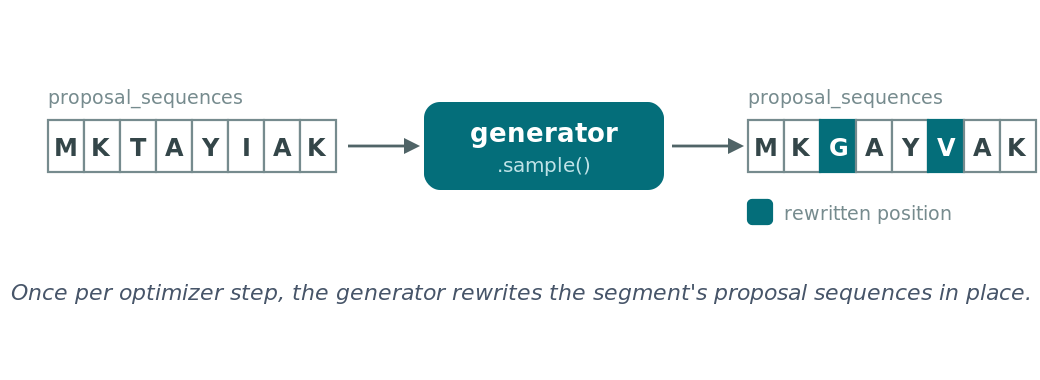

`sample()` operates on `segment.proposal_sequences`, a list of `Sequence` objects whose
`.sequence` strings are read and rewritten in place. A generator only proposes; duplication,
scoring, and selection remain the responsibility of the optimizer.

Every generator declares an `input_type`, a value of `GeneratorInputType` that determines how
the generator obtains its starting point and therefore the family to which it belongs:
`STARTING_SEQUENCE` (mutation), `PROMPT` (autoregressive), `STRUCTURE` (inverse folding), or
`LOGITS` (gradient).

## Generator families

<CardGroup cols={2}>
  <Card title="Mutation" icon="shuffle" href="/language/generators/mutation/overview">
    Introduces point changes to an existing sequence, suited to local search around a
    starting point. Examples: `RandomProteinGenerator`, `ESM2Generator`,
    `SemigreedyMutationGenerator`.
  </Card>
  <Card title="Autoregressive" icon="arrow-right" href="/language/generators/autoregressive/overview">
    Generates a sequence token by token from a prompt, suited to de novo generation.
    Examples: `ProGen2Generator`, `Evo2Generator`.
  </Card>
  <Card title="Inverse folding" icon="rotate-ccw" href="/language/generators/inverse_folding/overview">
    Designs a sequence for a fixed three-dimensional backbone. Examples:
    `ProteinMPNNGenerator`, `LigandMPNNGenerator`.
  </Card>
  <Card title="Gradient" icon="trending-down" href="/language/generators/gradient/overview">
    Optimizes a differentiable representation of the sequence. Example:
    `PositionWeightGenerator`, paired with the gradient optimizer.
  </Card>
</CardGroup>

The family is not specified directly; it is derived from the generator's `input_type`.

## Using a built-in generator

`RandomProteinGenerator` belongs to the mutation family: it replaces the residues at a set of
masked positions with random amino acids. The number of positions altered per call is governed
by a `MaskingStrategy`; optional `excluded_amino_acids` remove residues from the sampled mutation alphabet.
Because a generator only proposes, it can be exercised on its own by
supplying a starting sequence and calling `sample()` directly.

In [ ]:
from proto_language.core import Segment, Sequence
from proto_language.generator import RandomProteinGenerator, RandomProteinGeneratorConfig
from proto_tools.transforms.masking import MaskingStrategy

# A 20-residue protein segment to design.
design = Segment(length=20, sequence_type="protein", label="design")

# Change three positions per proposal, avoiding cysteine at sampled positions.
generator = RandomProteinGenerator(
    RandomProteinGeneratorConfig(
        masking_strategy=MaskingStrategy(num_mutations=3),
        excluded_amino_acids=["C"],
    )
)
generator.assign(design)

# Supply a starting sequence, then propose a single variant.
design.proposal_sequences = [
    Sequence(sequence="ADEFGHIKLMNPQRSTVWYV", sequence_type="protein"),
]

before = design.proposal_sequences[0].sequence
generator.sample()
after = design.proposal_sequences[0].sequence

changed = sum(1 for a, b in zip(before, after) if a != b)
print(f"before: {before}")
print(f"after:  {after}")
print(f"positions changed: {changed}")

## Defining a custom generator

A custom generator is a `Generator` subclass registered with the `@generator` decorator. It
declares an `input_type`, stores its configuration in `__init__`, and implements `_sample()`,
which rewrites each proposal sequence in place.

The generator below is biologically motivated. Instead of substituting arbitrary amino acids,
it replaces a residue only with a biochemically similar one drawn from a table of BLOSUM
neighbours. Such conservative substitutions are more likely to preserve a fold than
unconstrained ones.

In [ ]:
from typing import ClassVar
import random

from proto_language.core import Generator, GeneratorInputType
from proto_language.generator import generator
from proto_language.utils.base import BaseConfig, ConfigField

# Biochemically similar substitutions for each amino acid (abbreviated BLOSUM neighbours).
BLOSUM_NEIGHBORS = {
    "A": "GSTV", "R": "KQH", "N": "DQSH", "D": "NEQ", "C": "SA",
    "E": "DQK", "Q": "ENK", "G": "ASN", "H": "NQRY", "I": "VLM",
    "L": "IVM", "K": "RQE", "M": "ILV", "F": "YLW", "P": "AST",
    "S": "TANG", "T": "SANV", "W": "FYR", "Y": "FWH", "V": "ILM",
}


class ConservativeMutationConfig(BaseConfig):
    """Configuration for the conservative-substitution generator."""

    mutation_rate: float = ConfigField(
        default=0.1,
        ge=0.0,
        le=1.0,
        title="Mutation Rate",
        description="Fraction of positions to substitute per proposal",
    )


@generator(
    key="conservative-mutation",
    label="Conservative Mutation",
    config=ConservativeMutationConfig,
    description="Substitute residues with biochemically similar amino acids",
    supported_sequence_types=["protein"],
)
class ConservativeMutationGenerator(Generator):
    # STARTING_SEQUENCE places this generator in the mutation family.
    input_type: ClassVar[GeneratorInputType] = GeneratorInputType.STARTING_SEQUENCE

    def __init__(self, config: ConservativeMutationConfig):
        super().__init__()  # initialize base state (segment binding, RNG)
        self.config = config

    def _sample(self) -> None:
        for seq in self.segment.proposal_sequences:
            residues = list(seq.sequence.upper())

            for i, aa in enumerate(residues):
                # Substitute a position only with a biochemically similar residue.
                if random.random() < self.config.mutation_rate and BLOSUM_NEIGHBORS.get(aa):
                    residues[i] = random.choice(BLOSUM_NEIGHBORS[aa])

            seq.sequence = "".join(residues)

## Validating a generator

As with a constraint, a generator should be exercised in isolation before it is placed in an
optimizer. Assign it to a segment, supply a known starting sequence, call `sample()`, and
confirm that the sequence changes without a change in length or the introduction of invalid
residues.

In [ ]:
PROTEIN_ALPHABET = set("ACDEFGHIKLMNPQRSTVWY")

probe = Segment(length=20, sequence_type="protein", label="probe")
gen = ConservativeMutationGenerator(ConservativeMutationConfig(mutation_rate=0.5))
gen.assign(probe)

probe.proposal_sequences = [
    Sequence(sequence="ACDEFGHIKLMNPQRSTVWY", sequence_type="protein"),
]

original = probe.proposal_sequences[0].sequence
gen.sample()
result = probe.proposal_sequences[0].sequence

changed = sum(1 for a, b in zip(original, result) if a != b)
print(f"original: {original}")
print(f"result:   {result}")
print(f"positions changed: {changed}")

# The generator must propose a change, preserve length, and stay within the alphabet.
assert changed > 0
assert len(result) == len(original)
assert not (set(result) - PROTEIN_ALPHABET)

## Model-backed and gradient generators

Several of the built-in generators are backed by machine-learning models, yet they do not load
those models themselves. A generator such as `ESM2Generator` or `ProteinMPNNGenerator` stores
only its configuration in `__init__` and, in `_sample()`, calls a proto-tool that runs the
model. Model loading, environment isolation, and device placement are the responsibility of the
tools layer, and its persistence mechanism can keep a model warm across calls, so the model is
not reloaded on every optimization step. The generator declares the tool it depends on through
`tools_called`.

```python
@generator(
    key="esm2",
    label="ESM-2",
    config=ESM2GeneratorConfig,
    description="Propose protein mutations with the ESM-2 masked language model",
    uses_gpu=True,
    tools_called=["esm2-sample"],   # the model lives in the tools layer
    supported_sequence_types=["protein"],
)
class ESM2Generator(Generator):
    input_type: ClassVar[GeneratorInputType] = GeneratorInputType.STARTING_SEQUENCE

    def __init__(self, config: ESM2GeneratorConfig):
        super().__init__()
        self.config = config          # configuration only; no model is loaded here

    def _sample(self) -> None:
        sequences = [s.sequence for s in self.segment.proposal_sequences]
        # The model runs in the tools layer, which loads and persists it.
        result = run_esm2_sample(ESM2SampleInput(sequences=sequences), ESM2SampleConfig(...))
        for seq, mutated in zip(self.segment.proposal_sequences, result.sequences):
            seq.sequence = mutated
```

A model that is not wrapped as a tool can still be used by loading it directly. In that case the
model is loaded once in `__init__`, since `_sample()` runs on every step:

```python
class HFProteinMLMGenerator(Generator):
    def __init__(self, config: HFProteinMLMConfig):
        super().__init__()
        from transformers import AutoModelForMaskedLM, AutoTokenizer

        # Load once; _sample() reuses these on every step.
        self.tokenizer = AutoTokenizer.from_pretrained(config.model_name)
        self.model = AutoModelForMaskedLM.from_pretrained(config.model_name).eval()

    def _sample(self) -> None:
        ...  # mask positions, run the model, sample new residues from the logits
```

Gradient generators occupy the opposite end of the spectrum. `PositionWeightGenerator`
represents a sequence as a differentiable matrix of position weights and, paired with the
gradient optimizer, follows the gradient of differentiable objectives toward a design target.
The accompanying script applies this approach to two-stage de novo protein hallucination, in
which a continuous, soft sequence is progressively sharpened into a discrete one.

## Practical considerations

<Note>
A model-backed generator should delegate to the tools layer rather than load a model itself:
store configuration in `__init__` and call the model's tool from `_sample()`. The tools layer
loads the model and can keep it warm across calls, so it is not reloaded on every step. Only a
generator that wraps a model directly needs to load it once in `__init__`.
</Note>

<Tip>
A generator should preserve the segment's length and sequence type. Substitute residues in
place rather than inserting or deleting them, and draw only from the alphabet of the declared
`supported_sequence_types`.
</Tip>

<Note>
For reproducibility, set the seed at the program level by passing `seed=` to `Program` rather
than by calling `random.seed()` within a generator. The built-in generators draw from a
per-generator RNG that the framework seeds deterministically from the program seed.
</Note>

## Next Steps

<CardGroup cols={2}>
  <Card title="Using Constraints" icon="ruler" href="/language/guides/using-constraints">
    Define the objective the proposed sequences are scored against.
  </Card>
  <Card title="Using Optimizers" icon="circle-play" href="/language/guides/using-optimizers">
    Combine generators and constraints into a search.
  </Card>
  <Card title="Generators concept" icon="book" href="/language/concepts/generators">
    How generators relate to the rest of the model.
  </Card>
  <Card title="Generator reference" icon="list" href="/language/generators/random-protein">
    The complete catalog of built-in generators.
  </Card>
</CardGroup>